In [ ]:
import sys
!{sys.executable} -m pip install matplotlib seaborn plotly scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')


In [ ]:
df = pd.read_csv('data:/data.csv')
print(df.shape)
df.head(10)

**[önümde 12 kolon ve 10000 müşteri bulunduğunu fark ettim, bazı hesaplarda hiç para yok yani hesaplarında para tutmadıklarını anladım. hedef değişkenim churn hazır. ]**

In [ ]:
df.info()
df.isnull().sum()

In [ ]:
df.describe()

**ilk öncelikle bu tabloya baktığımda ortalama yaş kısmının 38 olduğunu fakat ortalama yaşın benim istediğim sonuçları vermediğini, çeyrek olarak nitelendirilen oranlara göre yorum yapmam gerektiğini anladım. müşterilerin çeyreği 32 yaşından küçük; yarısı 37 yaşından küçük; %75'i yani 3 çeyreklik kısmı ise 44 yaşından küçük. aynı şekilde bu hizmeti kullanmak için 18 yaşından büyük olmak gerektiğini de anladım. müşterilerin en az %50'si yani yarısı tek ürün kullanıyor. churn ortalamasına(mean) baktığım zaman ise 0.203700'lük oran müşterilerimizin yaklaşık %20'sinin kaçtığını gösteriyor. bu da verinin dengesizliğini gösteriyor ve model kurarken buna dikkat etmem gerekiyor.**

In [ ]:
df.groupby('products_number')['churn'].mean()

In [ ]:
df.groupby('products_number')['churn'].agg(['mean', 'count'])

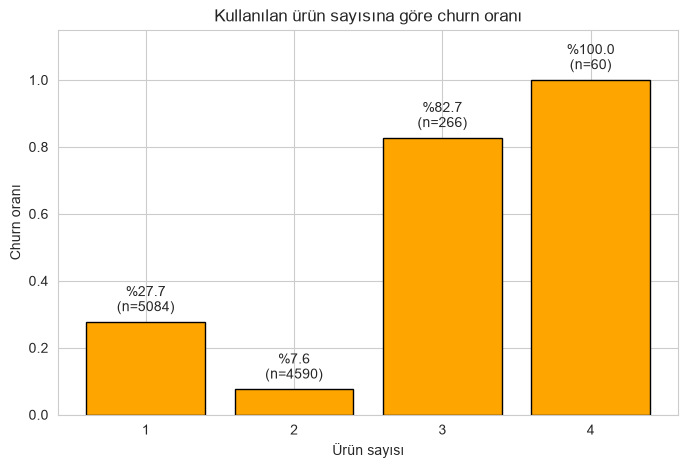

In [43]:
#kullanılan ürün sayısına göre churn oranı tablosu
stats = df.groupby('products_number')['churn'].agg(['mean', 'count'])

plt.figure(figsize=(8, 5))
bars = plt.bar(stats.index, stats['mean'], color='orange', edgecolor='black')

for bar, (mean, count) in zip(bars, zip(stats['mean'], stats['count'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'%{mean*100:.1f}\n(n={count})',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Ürün sayısı')
plt.ylabel('Churn oranı')
plt.title('Kullanılan ürün sayısına göre churn oranı')
plt.xticks([1, 2, 3, 4])
plt.ylim(0, 1.15)  
plt.savefig('figures/churn_by_products.png', dpi=150, bbox_inches='tight')
plt.show()

**ilk izlenimim olarak beklentimi karşılayan ve karşılamayan bir tablo olduğunu söyleyebilirim. bir ürün kullanan insanların terk etme oranı %27.7 iken 2 ürün kullanan insanların terk etme oranının büyük bir düşüşle %7.6'ya düşmesi şaşırtan bir sonuç olmadı benim için. fakat 3 ürün ve 4 ürün kullanan müşterilere bakınca terk etme oranı tam olarak bir U çiziyor, hatta beklentimi direkt olarak reddederek 4 ürün kullanan müşteriler 3 ürün kullananlardan daha fazla terk ediyor gibi gözüküyor fakat 10.000 müşterilik bir veri setinde 60 tane 4 ürün kullanan müşteri olunca buradaki 4 ürün kullanan müşterileri hesaba katmamam gerektiğini düşünüyorum. sonuç olarak vardığım kanı ilk iki örneklemde beklediğim sonuçları yani ürün sayısı-sadıklık skalasına uyan bir sonuç alıyorum. ilk iki örneklem için churn ile ürün sayısının ters orantılı olduğunu anlıyorum.**

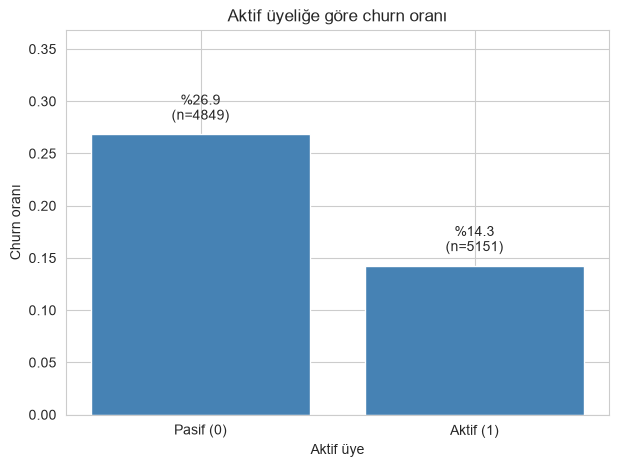

In [44]:
#aktif üyeliğe göre churn oranı tablosu
stats_active = df.groupby('active_member')['churn'].agg(['mean', 'count'])

plt.figure(figsize=(7, 5))
bars = plt.bar(stats_active.index, stats_active['mean'], color='steelblue', edgecolor='white')

for bar, (mean, count) in zip(bars, zip(stats_active['mean'], stats_active['count'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'%{mean*100:.1f}\n(n={count})',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Aktif üye')
plt.ylabel('Churn oranı')
plt.title('Aktif üyeliğe göre churn oranı')
plt.xticks([0, 1], ['Pasif (0)', 'Aktif (1)'])
plt.ylim(0, max(stats_active['mean']) + 0.1)
plt.savefig('figures/churn_by_active.png', dpi=150, bbox_inches='tight')
plt.show()

**gördüğüm şey yaklaşık %27'lik pasif hesap ve %14'lük aktif hesap ve pasif olan hesapların aktif olanlara göre terk etme oranının daha yüksek olduğu. bu oran yaklaşık olarak 2 kat fark ediyor ve bu verilere güvenebileceğimi düşünüyorum çünkü 2 örneklem sahibiyim ve sayılar çok yüksek. buradan çıkardığım sonuç müşteriyi aktif tutmanın terk etme oranını azalttığı. dolayısıyla pasif müşterileri aktif hale getirmek banka için daha fazla elde tutulan müşteri demek olabilir.**

In [45]:
df['ltv_proxy'] = df['balance'] * df['tenure']
df.groupby('churn')['ltv_proxy'].agg(['mean', 'median', 'count'])

,mean,median,count
churn,,,
0,362462.70640,198339.34,7963
1,454434.16377,361705.23,2037


**çıktıya göre kaçan müşteriler kalanlardan daha değerli gözüküyor. kaçanların medyan ltv proxy değeri yaklaşık 361.000 iken kalanların 198.000, yani neredeyse 2 kat fark var. burada dikkatimi çeken şey sadece ortalamanın değil medyanın da aynı yönü göstermesi, bu da bu farkın birkaç aşırı zengin müşteriden değil tipik kaçan müşteriden kaynaklandığını gösteriyor. yani banka değersiz müşterilerini değil tam tersine değerli müşterilerini kaybediyor, bu da churnu ciddi bir maliyet sorununa çeviriyor. not olarak ltv proxy gerçek bir ltv değil, balance ile tenure çarpımından türettiğim kaba bir gösterge.**

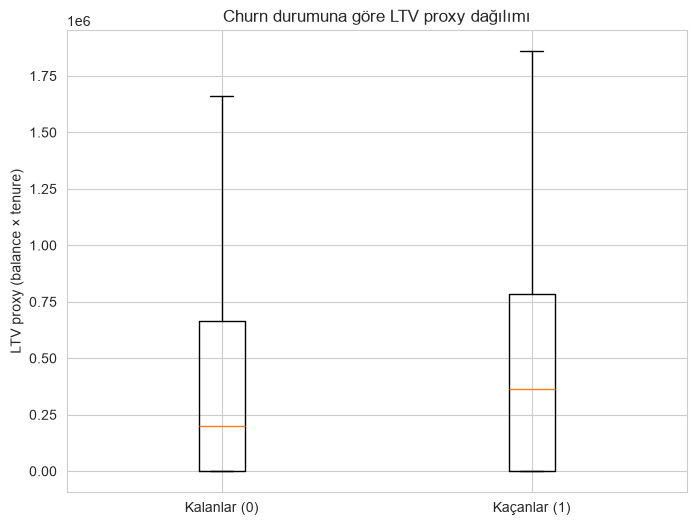

In [47]:
#LTV boxplot
plt.figure(figsize=(8, 6))

data_retained = df[df['churn'] == 0]['ltv_proxy']
data_churned = df[df['churn'] == 1]['ltv_proxy']

plt.boxplot([data_retained, data_churned],
            tick_labels=['Kalanlar (0)', 'Kaçanlar (1)'],
            showfliers=False)

plt.ylabel('LTV proxy (balance × tenure)')
plt.title('Churn durumuna göre LTV proxy dağılımı')
plt.savefig('figures/ltv_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()


**kaçan müşterilerim değeri kalanlarınkinden belirgin şekilde yüksek. bahsettiğim gibi bir çıktı alıyorum. genelde kaçanlar daha değerli ve değeri yüksek değerli müşterileri kaybettiği sonucuna kuvvetle varıyorum. !!burada LTV proxy değerim gerçek değil balance x tenure'dan ürettiğim bir çıktı.!!**

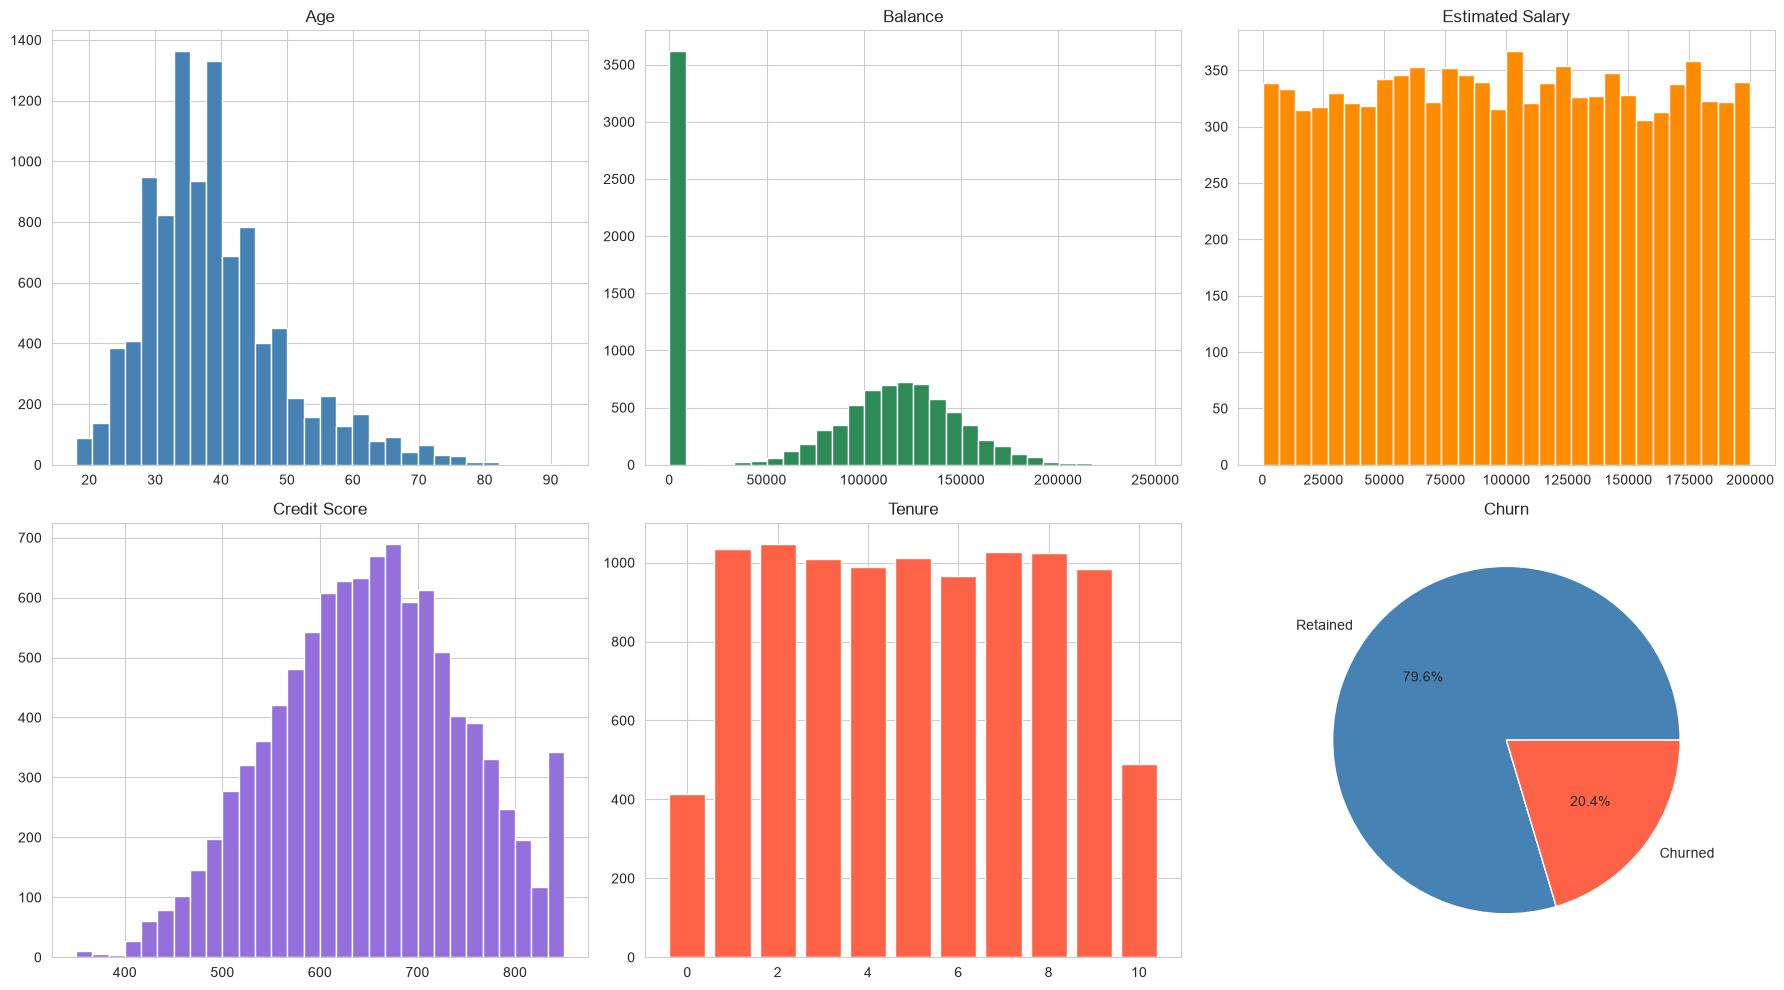

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Age')

axes[0, 1].hist(df['balance'], bins=30, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Balance')

axes[0, 2].hist(df['estimated_salary'], bins=30, color='darkorange', edgecolor='white')
axes[0, 2].set_title('Estimated Salary')

axes[1, 0].hist(df['credit_score'], bins=30, color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Credit Score')

axes[1, 1].bar(df['tenure'].value_counts().index, df['tenure'].value_counts().values, color='tomato')
axes[1, 1].set_title('Tenure')

axes[1, 2].pie(df['churn'].value_counts(), labels=['Retained', 'Churned'],
               autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1, 2].set_title('Churn')

plt.tight_layout()
plt.savefig('figures/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**2.KISIM **

In [37]:
from sklearn.model_selection import train_test_split


df_model = df.drop(columns=['customer_id', 'ltv_proxy'], errors='ignore') #kolon siliyorum


df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0}) #modelin anlaması için gender'ı sayılarla tanımlıyorum.


df_model = pd.get_dummies(df_model, columns=['country'], drop_first=True) #country churn'ü etkilediği için getdummies kullanıyorum.


X = df_model.drop(columns=['churn'])
y = df_model['churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Kolonlar:", list(X.columns))

Train: (8000, 11)
Test: (2000, 11)
Kolonlar: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain']


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#modelimi kuruyorum.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#verilerde tahmin yapıyorum.
y_pred = model.predict(X_test)

#çıktılarımı alıyorum.
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[1543   50]
 [ 332   75]]

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.60      0.18      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



**%81 doğruluk oranı aldım ama bunun yanıltıcı olduğunu düşünüyorum. daha önceden de bahsettiğim gibi veri çok dengesiz. churn edenlerin sadece %18'ni yakalayabiliyor bu da gerçekte kaçanların büyük bir kısmını kaçırması demek. yüksek bir doğruluk tutturmasına rağmen kaçanları yakalayamıyor o yüzden kaçanları kaçırmamaya odaklanmam gerekiyor. yukarda bahsettiğim gibi amaç müşteriyi önceden yakalamak. dengesizliği modele bildirip daha güçlü bir model deneyeceğim.**

In [39]:
from sklearn.ensemble import RandomForestClassifier

# daha güçlü model kurup dengesizliği bildiriyorum.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

[[1318  275]
 [ 106  301]]

              precision    recall  f1-score   support

           0       0.93      0.83      0.87      1593
           1       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



**model artık gerçekte kaçanların artık %74'nü yakalıyor ki bu benim istediğim bir şeydi fakat precision %60'tan %52'ye düştü. bu iş açısından kabul edilebilir bir takas. bankanın kaçacak bir müşteriyi kaçırması, kalacak birine kampanya göndermesinden daha maliyetli. hedefime daha uygun bir model.**

             feature  importance
2                age    0.375138
5    products_number    0.242354
4            balance    0.098547
7      active_member    0.064876
9    country_Germany    0.064233
0       credit_score    0.048566
8   estimated_salary    0.047438
3             tenure    0.023812
1             gender    0.022009
10     country_Spain    0.006852
6        credit_card    0.006176


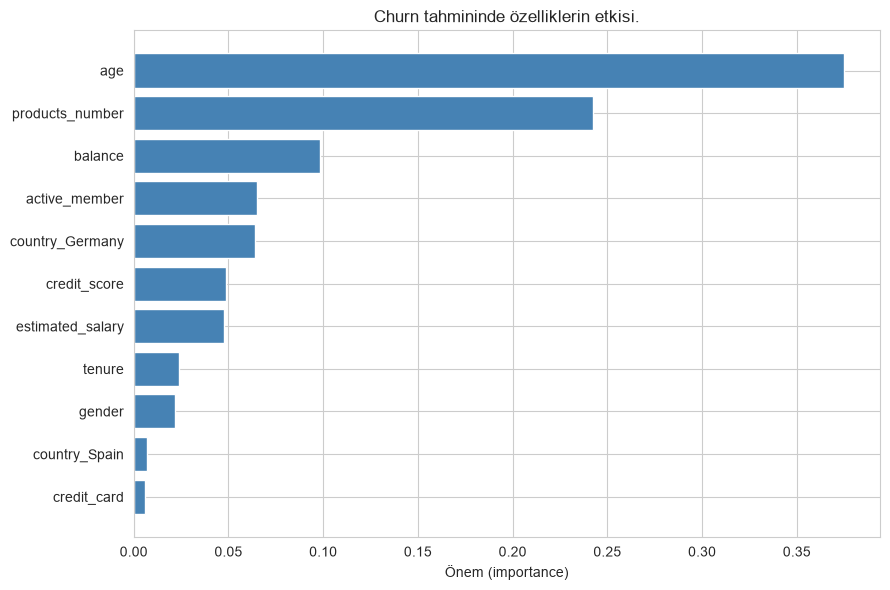

In [49]:
# özellik-churn dengesi.
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feat_imp)

#grafk oluşturuyorum.
plt.figure(figsize=(9, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
plt.xlabel('Önem (importance)')
plt.title('Churn tahmininde özelliklerin etkisi.')
plt.gca().invert_yaxis()   # en önemli en üstte olsun
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**özellik-churn dengesi grafiğim h1 ve h2 hipotezimi onayladı. h1'de elle bulduğum products_number en önemli ikinci faktörken, h2'de bulduğum active_member ise en önemli değişkenler arasında. sezgisel analizimle modelim aynı sonuca vardı. burada beklemediğim etken age'di. ayrıca getdummies ile ayırdığım ülkeler de büyük bir etken olarak karşımıza çıkıyor. ilk başta country kısmını direkt silmeyi düşünmüştüm ama şu an yaptığım şey daha doğru olduğunu anlamamı sağlıyor.**